# Loadings heatmap

The per-component loadings plot shows one component at a time. The heatmap shows them all at once: variables down the rows, components across the columns, each cell colored by the loading it holds.

    plot_loadings_heatmap(loadings; comps = [...], varnames = ..., compnames = ..., nonzero = ..., ntop = ..., kwargs...)

That layout answers a question the single-component view cannot — whether components 1 and 3 pick out overlapping variables, and whether they agree on the sign. The color scale is diverging and centered at zero, so a positive loading reads warm, a negative one cool, and anything near zero settles into the midtone.

It takes the same loadings matrix as before, variables in rows and components in columns.

## Setup

In [1]:
using BigRiverEssence
using WolfRiverPlots
using Plots
using StableRNGs

## A simulated example

The same three latent signals driving twenty variables. We fit a dense PCA and, further down, a sparse one — the two read very differently on a heatmap, and the difference is the reason this plot exists.

In [2]:
rng = StableRNG(20240801)

n = 90    # observations
p = 20    # variables

latent = randn(rng, n, 3)
X = latent * randn(rng, 3, p) .+ 0.3 .* randn(rng, n, p)

vnames = ["gene$(i)" for i in 1:p]

m = pca(X; k = 4)

size(m.loadings)   # variables by components

(20, 4)

## The default plot

Given nothing but the loadings, we get every variable against every component, both axes ticked by index, with a colorbar showing the scale. The scale is padded symmetrically about zero, so warm and cool are directly comparable.

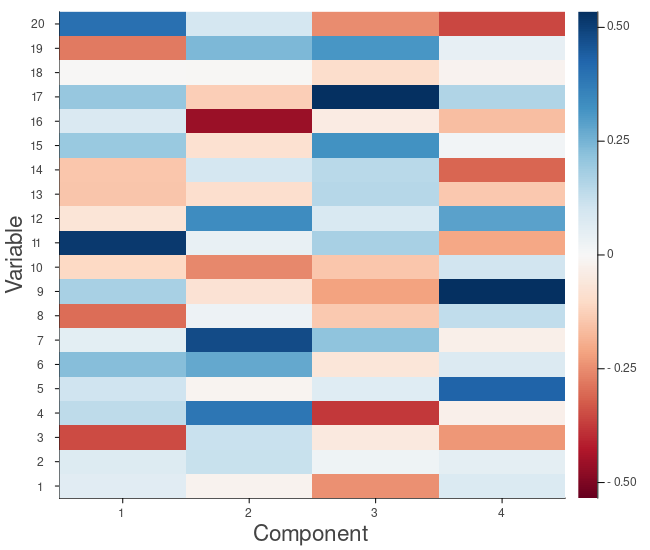

In [3]:
plot_loadings_heatmap(m.loadings)

---

# Modifying the plot

The arguments that change **what we draw** are close cousins of the ones on the loadings plot, with two differences worth flagging.

`comps` here is a **vector** of components, not a single one — that is the whole point of the heatmap, so we can compare several side by side. And `ntop` ranks each variable by the largest loading it reaches on **any** of the components drawn, so a variable that is negligible on the first component but dominant on the third still earns its row. The survivors are then put back into variable order, so the axis still reads the way the data does.

## Naming and selecting

`varnames` names the rows and `compnames` the columns; both are subset along with the matrix, so the labels stay correct whatever we filter. `ntop` keeps only the variables that matter somewhere, which is what keeps the row axis legible on a real data set.

Here we take the six strongest variables across the first three components.

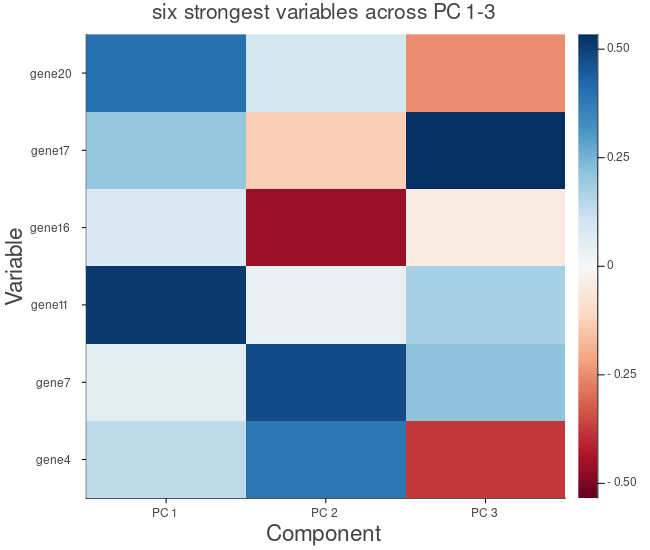

In [4]:
plot_loadings_heatmap(m.loadings;
                      comps     = [1, 2, 3],
                      varnames  = vnames,
                      compnames = ["PC $(j)" for j in 1:4],
                      ntop      = 6,
                      title     = "six strongest variables across PC 1-3")

## A sparse fit, with and without the zeros

This is where the heatmap earns its keep. A model with an L1 penalty drops most variables on most components, and on the map those dropped cells all land on the midtone — so we can see at a glance which variables each component selected, and whether the components overlap.

First the full picture, every variable kept, mostly blank:

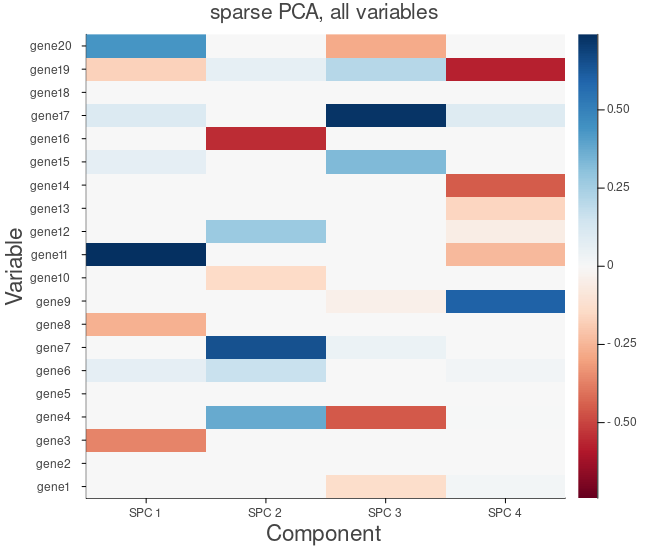

In [5]:
m_spc = spc(X; k = 4, c = sqrt(p) / 2)

plot_loadings_heatmap(m_spc.loadings;
                      varnames  = vnames,
                      compnames = ["SPC $(j)" for j in 1:4],
                      title     = "sparse PCA, all variables")

Now with `nonzero = true`, which drops any variable the penalty zeroed out on **every** component drawn. A row of zeros carries nothing and only squeezes the rest of the map, so removing them makes the selected structure far easier to read.

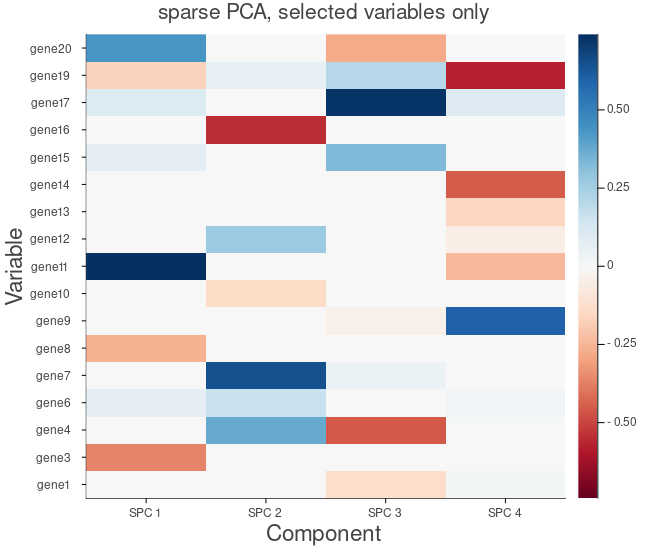

In [6]:
plot_loadings_heatmap(m_spc.loadings;
                      varnames  = vnames,
                      compnames = ["SPC $(j)" for j in 1:4],
                      nonzero   = true,
                      title     = "sparse PCA, selected variables only")

## Color and the rest

`heatmapcolor` sets the scheme and defaults to `:RdBu`. Any diverging scheme works — `:balance` and `:coolwarm` are the usual alternatives — but a diverging one matters here, since the sign of a loading is meaningful and a sequential scheme would hide it.

`maxnames` is the cutoff past which the row labels are dropped for numeric ticks, because names stop being legible once there are too many to fit. It defaults to 40; lowering it forces the plot back to indices.

Everything else the plot sets for itself yields to what we pass — including `colorbar`, worth turning off when the figure sits beside others sharing one scale.

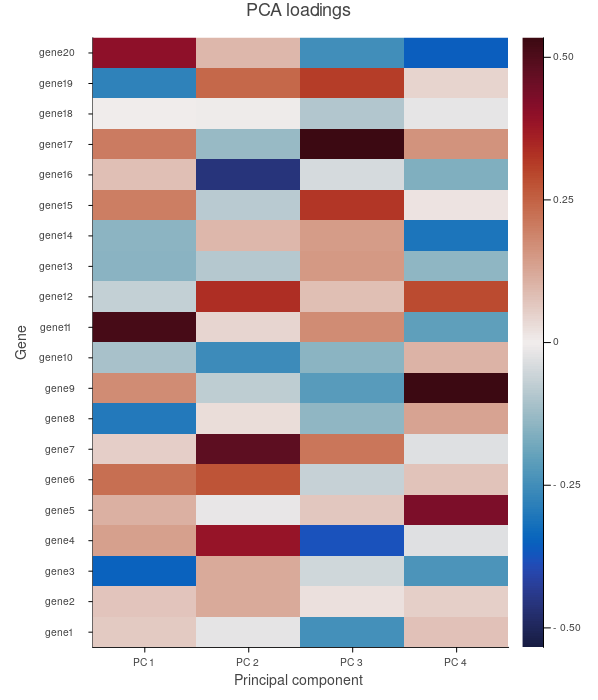

In [8]:
plot_loadings_heatmap(m.loadings;
                      varnames      = vnames,
                      compnames     = ["PC $(j)" for j in 1:4],
                      heatmapcolor  = :balance,
                      xlabel        = "Principal component",
                      ylabel        = "Gene",
                      title         = "PCA loadings",
                      colorbar      = true,
                      size          = (600, 700),
                      left_margin        = (5,:mm),
                      guidefontsize = 11)